## Introduction
This notebook steps to export skeletons body measurements obtained from motion capture data. It includes functionalities to load CSV files containing the skeleton data, extract the 3D positions of relevant bones, calculate specific measurements (such as shoulder width, arm lengths, leg lengths, and overall height), visualize the bone positions in 3D space, and export them into a spreadsheet.

The notebook is designed to compare the generated skeletons with manual human (tape-based) measurements, allowing for an accurate assessment of the data's quality and consistency.

### Measurements Calculated
The following measurements are extracted from the motion capture skeleton data:
- Standing height
- Sitting height
- Wingspan
- Upper leg length
- Biacromial breadth
- Upper arm length
- Foot length

### Data Structure
The expected CSV file structure is described in [Motive's data export documentation](https://docs.optitrack.com/motive/data-export/data-export-csv) includes the following rows:
- 1st row: General information about the take and export settings.
- 3rd row: Data type (e.g., bone) for each corresponding column.
- 4th row: Marker or asset labels (bone names).
- 6th and 7th row: Header label for the data included in the column (position and orientation on X/Y/Z).
- Subsequent rows: Frame data with X/Y/Z positions and W/X/Y/Z rotation quaternion for each bone.

Let's start by loading the CSV files and extracting the relevant data.

#### Note 
This notebook, including the code, was primarily developed by one researcher in collaboration with ChatGPT (@HaukeCornell). To view the initial code generation process, view the [chat history](https://chat.openai.com/share/b2772194-61dc-45ff-bd64-c4eba589cb58). It has undergone iterations and refinements, incorporating a visualization and utilizing various skeletal measurements. For further details on these enhancements, refer to [the continued code generation conversation](https://chat.openai.com/share/b2772194-61dc-45ff-bd64-c4eba589cb58). Although the code has undergone a preliminary review by a second researcher, it has not been thoroughly vetted and may contain inaccuracies. We advise using it with caution.


# Load Skeleton Data From Frames And Assess Its Format

In [23]:
%matplotlib ipympl

# Importing required libraries
import csv

# Function to extract bone names and position data from the CSV file
def extract_bone_data(file_path):
    bone_names = []
    frames_data = []
    with open(file_path, 'r') as file:
        # Skip the first 3 rows
        for _ in range(3):
            file.readline()
        # Read the 4th row to extract the bone names corresponding to the position columns (every 7th starting from 6th)
        bone_names_line = file.readline().strip().split(",")
        bone_names = [bone_names_line[i] for i in range(6, len(bone_names_line), 7)]
        # Skip rows 5, 6, and 7
        for _ in range(3):
            file.readline()
        # Iterate through the remaining rows to extract position data for each frame
        for line in file:
            frame_data = line.strip().split(",")
            # Extract X, Y, Z position data for each bone (every 7th starting from 6th)
            positions = [(float(frame_data[i]), float(frame_data[i + 1]), float(frame_data[i + 2])) for i in range(6, len(frame_data), 7)]
            frames_data.append(positions)
    return bone_names, frames_data


In [24]:
# Path to the CSV file containing the skeleton data
file_path = "Public_Test_Data/MotionCapture_CSVExport/0-10/M-SMC-06262023-03.csv"  # Update this path

# Extracting bone names and position data
bone_names, frames_data = extract_bone_data(file_path)

# Displaying the bone names and the corresponding XYZ positions for the first frame
bone_names_and_positions_first_frame = list(zip(bone_names, frames_data[0]))
bone_names_and_positions_first_frame

[('SMC-06262023-03:Hip', (29.778948, 913.248169, -183.050034)),
 ('SMC-06262023-03:Ab', (29.55496, 1007.215881, -183.990829)),
 ('SMC-06262023-03:Chest', (26.225115, 1211.456177, -221.794601)),
 ('SMC-06262023-03:Neck', (25.855099, 1376.270508, -239.638535)),
 ('SMC-06262023-03:Head', (15.75296, 1463.375, -188.63327)),
 ('SMC-06262023-03:LShoulder', (61.742844, 1382.349487, -243.953949)),
 ('SMC-06262023-03:LUArm', (126.964348, 1342.627075, -234.654617)),
 ('SMC-06262023-03:LFArm', (225.362762, 1052.911255, -146.894333)),
 ('SMC-06262023-03:LHand', (270.063721, 883.752136, 10.357782)),
 ('SMC-06262023-03:RShoulder', (-10.196836, 1382.781738, -238.468674)),
 ('SMC-06262023-03:RUArm', (-75.013489, 1345.484497, -220.416183)),
 ('SMC-06262023-03:RFArm', (-184.207062, 1061.074341, -128.182068)),
 ('SMC-06262023-03:RHand', (-232.88237, 879.269287, 12.951732)),
 ('SMC-06262023-03:LThigh', (119.688087, 913.388733, -190.416397)),
 ('SMC-06262023-03:LShin', (126.55719, 506.845825, -176.677505)),

### Euclidean distance measurements

In [25]:
# Function to calculate Euclidean distance between two points
def calculate_distance(bone1, bone2, positions):
    x1, y1, z1 = positions[bone_names.index(bone1)]
    x2, y2, z2 = positions[bone_names.index(bone2)]
    return ((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2) ** 0.5

# Measurements to be calculated (Update the bone names according to the specific naming convention in your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]
measurements = {
    # "Shoulder Width": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm"),
    "Shoulder Width": (f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:RShoulder"),
    "Upper Arm Length (Left)": (f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LFArm"),
    "Lower Arm Length (Left)": (f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:LHand"),
    "Upper Arm Length (Right)": (f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm"),
    "Lower Arm Length (Right)": (f"{skeleton_identifier}:RFArm", f"{skeleton_identifier}:RHand"),
    "Upper Leg Length (Left)": (f"{skeleton_identifier}:LThigh", f"{skeleton_identifier}:LShin"),
    "Lower Leg Length (Left)": (f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"),
    "Upper Leg Length (Right)": (f"{skeleton_identifier}:RThigh", f"{skeleton_identifier}:RShin"),
    "Lower Leg Length (Right)": (f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RFoot"),
}

# Calculating the measurements for the first 10 frames
all_frame_measurements = []
for frame_positions in frames_data[:10]:
    frame_measurements = {name: calculate_distance(bone1, bone2, frame_positions) for name, (bone1, bone2) in measurements.items()}
    # Calculating overall height (average of Left and Right Feet to Head)
    frame_measurements["Overall Height"] = (calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:LFoot", frame_positions) +
                                            calculate_distance(f"{skeleton_identifier}:Head", f"{skeleton_identifier}:RFoot", frame_positions)) / 2
    all_frame_measurements.append(frame_measurements)

all_frame_measurements



[{'Shoulder Width': 72.14979307839369,
  'Upper Arm Length (Left)': 318.3070399531693,
  'Lower Arm Length (Left)': 235.24712739659347,
  'Upper Arm Length (Right)': 318.30724966655066,
  'Lower Arm Length (Right)': 235.24691872855163,
  'Upper Leg Length (Left)': 406.8329851112232,
  'Lower Leg Length (Left)': 436.35696772359364,
  'Upper Leg Length (Right)': 406.8331196245021,
  'Lower Leg Length (Right)': 436.3571252820766,
  'Overall Height': 1397.0111659227136},
 {'Shoulder Width': 72.14981321895752,
  'Upper Arm Length (Left)': 318.30718028957926,
  'Lower Arm Length (Left)': 235.24706366162758,
  'Upper Arm Length (Right)': 318.30722834219085,
  'Lower Arm Length (Right)': 235.2469757942302,
  'Upper Leg Length (Left)': 406.83317923951313,
  'Lower Leg Length (Left)': 436.3571898242587,
  'Upper Leg Length (Right)': 406.8331408372155,
  'Lower Leg Length (Right)': 436.35722411801765,
  'Overall Height': 1418.5786036330644},
 {'Shoulder Width': 72.14979591725398,
  'Upper Arm Len

### Accumulate using numpy

In [26]:
# Import necessary libraries
import numpy as np

# Function to calculate Euclidean distance between two points
def calculate_distance(point1, point2):
    return np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2 + (point1[2] - point2[2]) ** 2)

# Function to calculate accumulated distance between a list of bones
def calculate_accumulated_distance(bones, positions):
    distance = 0
    for i in range(len(bones) - 1):
        distance += calculate_distance(positions[bone_names.index(bones[i])], positions[bone_names.index(bones[i + 1])])
    return distance

# Bones of interest (Update these according to the specific naming convention in your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Define lists of bones for accumulated measurements
shoulder_bones = [f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:RUArm"]
height_bones = [f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RThigh", f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:Ab", f"{skeleton_identifier}:Head"]
leg_bones_left = [f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LThigh"]
leg_bones_right = [f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RShin", f"{skeleton_identifier}:RThigh"]
arm_bones_left = [f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:LFArm", f"{skeleton_identifier}:LUArm"]
arm_bones_right = [f"{skeleton_identifier}:RHand", f"{skeleton_identifier}:RFArm", f"{skeleton_identifier}:RUArm"]

# Example: Calculating the accumulated distances for the first frame
frame_positions = frames_data[0]
shoulder_width_accumulated = calculate_accumulated_distance(shoulder_bones, frame_positions)
total_height_accumulated = calculate_accumulated_distance(height_bones, frame_positions)
total_leg_length_accumulated_left = calculate_accumulated_distance(leg_bones_left, frame_positions)
total_leg_length_accumulated_right = calculate_accumulated_distance(leg_bones_right, frame_positions)
total_arm_length_accumulated_left = calculate_accumulated_distance(arm_bones_left, frame_positions)
total_arm_length_accumulated_right = calculate_accumulated_distance(arm_bones_right, frame_positions)

# Print the calculated measurements for verification
measurements_accumulated = {
    "Shoulder Width (Accumulated)": shoulder_width_accumulated,
    "Total Height (Accumulated)": total_height_accumulated,
    "Total Leg Length (Accumulated, Left)": total_leg_length_accumulated_left,
    "Total Leg Length (Accumulated, Right)": total_leg_length_accumulated_right,
    "Total Arm Length (Accumulated, Left)": total_arm_length_accumulated_left,
    "Total Arm Length (Accumulated, Right)": total_arm_length_accumulated_right,
}
measurements_accumulated


{'Shoulder Width (Accumulated)': 202.49924568367413,
 'Total Height (Accumulated)': 1483.7649285261534,
 'Total Leg Length (Accumulated, Left)': 843.1899528348168,
 'Total Leg Length (Accumulated, Right)': 843.1902449065788,
 'Total Arm Length (Accumulated, Left)': 553.5541673497628,
 'Total Arm Length (Accumulated, Right)': 553.5541683951024}

## Check for Measurement stability over frames

In [27]:
# Function to calculate measurements for multiple frames
def calculate_measurements_for_frames(frames_data, bone_names):
    # Update these bone names according to your specific naming convention
    skeleton_identifier = bone_names[0].split(":")[0]
    left_shoulder = f"{skeleton_identifier}:LShoulder"
    right_shoulder = f"{skeleton_identifier}:RShoulder"
    
    # Calculating the measurements for each frame
    all_frame_measurements = []
    for frame_positions in frames_data:
        # Distance from left shoulder to right shoulder
        shoulder_width = calculate_distance(frame_positions[bone_names.index(left_shoulder)], frame_positions[bone_names.index(right_shoulder)])
        
        # Add other measurements as needed
        frame_measurements = {
            "Shoulder Width": shoulder_width,
            # Add other measurements here...
        }
        all_frame_measurements.append(frame_measurements)
    
    return all_frame_measurements

# Calculating the measurements for the first 10 frames and printing them
measurements_first_10_frames = calculate_measurements_for_frames(frames_data[:10], bone_names)
measurements_first_10_frames


[{'Shoulder Width': 72.14979307839369},
 {'Shoulder Width': 72.14981321895752},
 {'Shoulder Width': 72.14979591725398},
 {'Shoulder Width': 72.14983885235381},
 {'Shoulder Width': 72.14977802426296},
 {'Shoulder Width': 72.14981448260193},
 {'Shoulder Width': 72.14980343411135},
 {'Shoulder Width': 72.14982424247242},
 {'Shoulder Width': 72.14980467200274},
 {'Shoulder Width': 72.14981765815833}]

In [28]:
# Function to calculate measurements for multiple frames
def calculate_measurements_for_frames(frames_data, bone_names):
    # Update these bone names according to your specific naming convention
    skeleton_identifier = bone_names[0].split(":")[0]
    left_shoulder = f"{skeleton_identifier}:LUArm"
    right_shoulder = f"{skeleton_identifier}:RUArm"
    # neck = f"{skeleton_identifier}:Neck"  # Update this if different
    # neck = f"{skeleton_identifier}:Chest"  # Update this if different
    neck = f"{skeleton_identifier}:Head"  # Update this if different

    # Calculating the measurements for each frame
    all_frame_measurements = []
    for frame_positions in frames_data:
        # Distance from shoulders to neck
        left_shoulder_to_neck = calculate_distance(frame_positions[bone_names.index(left_shoulder)], frame_positions[bone_names.index(neck)])
        right_shoulder_to_neck = calculate_distance(frame_positions[bone_names.index(right_shoulder)], frame_positions[bone_names.index(neck)])
        
        # Accumulated shoulder width: sum of left and right shoulder-to-neck distances
        shoulder_width_accumulated = left_shoulder_to_neck + right_shoulder_to_neck
        
        # Add other measurements as needed
        frame_measurements = {
            "Shoulder Width (Accumulated)": shoulder_width_accumulated,
            # Add other measurements here...
        }
        all_frame_measurements.append(frame_measurements)
    
    return all_frame_measurements

# Calculating the measurements for the first 10 frames and printing them
measurements_first_10_frames = calculate_measurements_for_frames(frames_data[:10], bone_names)
measurements_first_10_frames


[{'Shoulder Width (Accumulated)': 322.62849473745723},
 {'Shoulder Width (Accumulated)': 370.583409369782},
 {'Shoulder Width (Accumulated)': 381.6745371925817},
 {'Shoulder Width (Accumulated)': 393.2296697236766},
 {'Shoulder Width (Accumulated)': 405.4703205225635},
 {'Shoulder Width (Accumulated)': 414.86168406437105},
 {'Shoulder Width (Accumulated)': 420.31290032794305},
 {'Shoulder Width (Accumulated)': 422.00793118883894},
 {'Shoulder Width (Accumulated)': 421.00491338966236},
 {'Shoulder Width (Accumulated)': 418.822716742772}]

In [29]:
def calculate_bone_length(bone1, bone2, frame_positions, bone_names):
    p1 = frame_positions[bone_names.index(bone1)]
    p2 = frame_positions[bone_names.index(bone2)]
    return calculate_distance(p1, p2)

def calculate_measurements(frame_positions, bone_names):
    # Using bone names specific to your data, update accordingly
    skeleton_identifier = bone_names[0].split(":")[0]
    
    # Define the bones involved in each measurement
    standing_height_bones = [
        f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest", f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:LThigh",
        f"{skeleton_identifier}:LShin", f"{skeleton_identifier}:LFoot"
    ]
    
    upper_leg_length_bones_L = [
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:LThigh"
    ]
    upper_leg_length_bones_R = [
        f"{skeleton_identifier}:Hip", f"{skeleton_identifier}:RThigh"
    ]
    
    upper_arm_length_bones_L = [
        f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LFArm"
    ]
    upper_arm_length_bones_R = [
        f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm"
    ]
    wingspan_bones = [
        f"{skeleton_identifier}:LHand", f"{skeleton_identifier}:LFArm",
        f"{skeleton_identifier}:LUArm", f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck", f"{skeleton_identifier}:RShoulder",
        f"{skeleton_identifier}:RUArm", f"{skeleton_identifier}:RFArm",
        f"{skeleton_identifier}:RHand"
    ]
    
    sitting_height_bones = [
        f"{skeleton_identifier}:Head", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest", f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip"
    ]
    
    biacromial_breadth_bones = [
        f"{skeleton_identifier}:LShoulder", f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder"
    ]

    left_foot_bones = [
        f"{skeleton_identifier}:LFoot", f"{skeleton_identifier}:LToe"
    ]
    right_foot_bones = [
        f"{skeleton_identifier}:RFoot", f"{skeleton_identifier}:RToe"
    ]

    # Calculating the lengths
    standing_height = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(standing_height_bones[:-1], standing_height_bones[1:]))
    
    upper_leg_length_L = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_leg_length_bones_L[:-1], upper_leg_length_bones_L[1:]))
    upper_leg_length_R = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_leg_length_bones_R[:-1], upper_leg_length_bones_R[1:]))
    
    upper_arm_length_L = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_arm_length_bones_L[:-1], upper_arm_length_bones_L[1:]))
    upper_arm_length_R = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(upper_arm_length_bones_R[:-1], upper_arm_length_bones_R[1:]))
    
    left_foot_length = calculate_bone_length(left_foot_bones[0], left_foot_bones[1], frame_positions, bone_names)
    right_foot_length = calculate_bone_length(right_foot_bones[0], right_foot_bones[1], frame_positions, bone_names)
    
    # Taking the maximum of the two as the foot length to estimate shoe size
    foot_length = max(left_foot_length, right_foot_length)
    
    # Placeholder for any conversion to shoe size (this might need a specific formula or lookup table)
    estimated_shoe_size = (foot_length / 25.4 - 1) * 1.5 + 1 # US sizing system

    # Selecting the longer of the left and right for bilateral measurements
    upper_leg_length = max(upper_leg_length_L, upper_leg_length_R)
    upper_arm_length = max(upper_arm_length_L, upper_arm_length_R)
    wingspan = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(wingspan_bones[:-1], wingspan_bones[1:]))
    sitting_height = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(sitting_height_bones[:-1], sitting_height_bones[1:]))
    biacromial_breadth = sum(calculate_bone_length(b1, b2, frame_positions, bone_names) for b1, b2 in zip(biacromial_breadth_bones[:-1], biacromial_breadth_bones[1:]))
    
    return {
        "Standing Height": standing_height,
        "Upper Leg Length": upper_leg_length,
        "Upper Arm Length": upper_arm_length,
        "Wingspan": wingspan,
        "Sitting Height = Upper Body Height": sitting_height,
        "Biacromial Breadth": biacromial_breadth,
        "Foot Length": foot_length,
        "Estimated Shoe Size": estimated_shoe_size
    }


# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
calculate_measurements(frames_data[0], bone_names)


{'Standing Height': 1502.3306898833994,
 'Upper Leg Length': 90.21051123792164,
 'Upper Arm Length': 318.30724966655066,
 'Wingspan': 1334.275558097647,
 'Sitting Height = Upper Body Height': 568.9302258106608,
 'Biacromial Breadth': 73.30775856586115,
 'Foot Length': 147.47442096821914,
 'Estimated Shoe Size': 8.209119348516879}

# Visualize Chosen Measurements

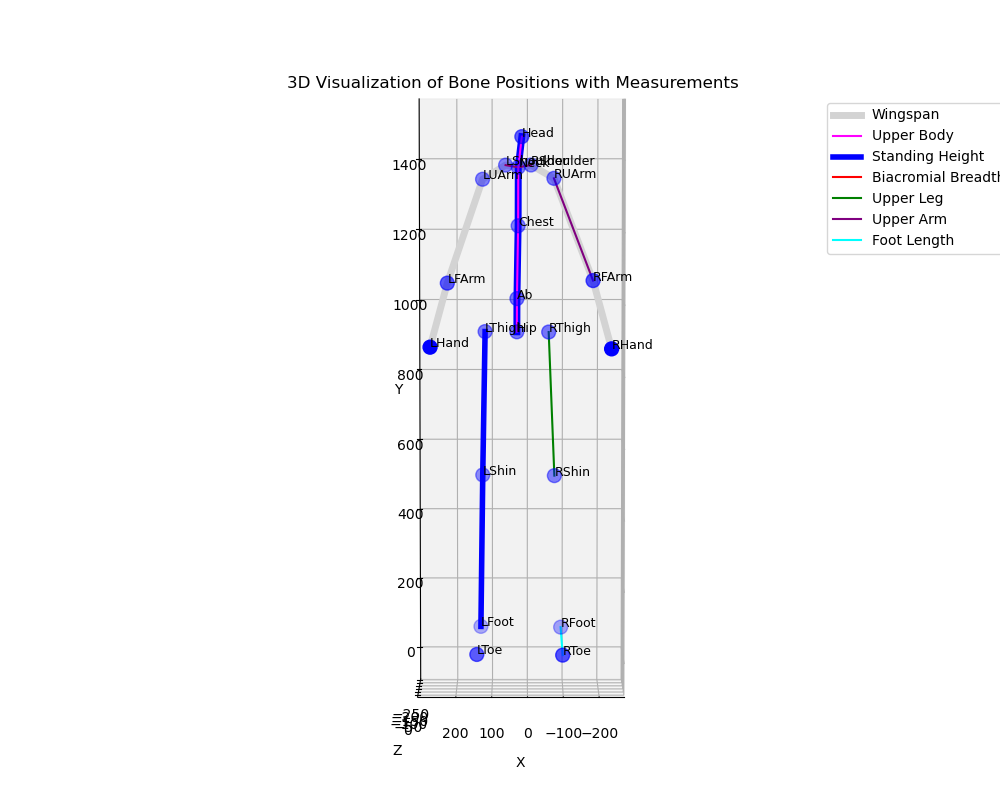

In [30]:
import matplotlib.pyplot as plt

%matplotlib widget
def calculate_distance(p1, p2):
    # Helper function to calculate distance between two points
    return ((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2) ** 0.5

def plot_full_measurements(frame_positions, bone_names):
    ...
    # Define the bone sequences for each measurement
    upper_body_bones = [
        f"{skeleton_identifier}:Head",
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:Chest",
        f"{skeleton_identifier}:Ab",
        f"{skeleton_identifier}:Hip"
    ]
    
    wingspan_bones_L = [
        f"{skeleton_identifier}:LHand",
        f"{skeleton_identifier}:LFArm",
        f"{skeleton_identifier}:LUArm",
        f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck"
    ]
    wingspan_bones_R = [
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder",
        f"{skeleton_identifier}:RUArm",
        f"{skeleton_identifier}:RFArm",
        f"{skeleton_identifier}:RHand"
    ]
    leg_bones_L = [
        f"{skeleton_identifier}:LThigh",
        f"{skeleton_identifier}:LShin",
        f"{skeleton_identifier}:LFoot"
    ]
    upper_leg_bones_L = [
        f"{skeleton_identifier}:LThigh",
        f"{skeleton_identifier}:LShin"
    ]
    upper_leg_bones_R = [
        f"{skeleton_identifier}:RThigh",
        f"{skeleton_identifier}:RShin"
    ]
    
    upper_arm_bones_L = [
        f"{skeleton_identifier}:LUArm",
        f"{skeleton_identifier}:LFArm"
    ]
    upper_arm_bones_R = [
        f"{skeleton_identifier}:RUArm",
        f"{skeleton_identifier}:RFArm"
    ]

    foot_bones_L = [
        f"{skeleton_identifier}:LFoot",
        f"{skeleton_identifier}:LToe"
    ]
    foot_bones_R = [
        f"{skeleton_identifier}:RFoot",
        f"{skeleton_identifier}:RToe"
    ]
    biacromial_breadth_bones = [
        f"{skeleton_identifier}:LShoulder",
        f"{skeleton_identifier}:Neck",
        f"{skeleton_identifier}:RShoulder",
    ]
    

    # Grouping for iteration    
    continuous_measurements = [
        (wingspan_bones_L + wingspan_bones_R, "lightgrey", "Wingspan", 5.0),
        (upper_body_bones, "blue", "Upper Body", 5.0),
        (leg_bones_L, "blue", "Standing Height", 4.0)
    ]

    measurement_groups = [
        (biacromial_breadth_bones, "red", "Biacromial Breadth", 1.5),
        (upper_body_bones, "magenta", "Upper Body", 1.5),
        # (upper_leg_bones_L, "green", "Upper Leg", 1.5),
        (upper_leg_bones_R, "green", "Upper Leg", 1.5),
        # (upper_arm_bones_L, "purple", "Upper Arm", 1.5),
        (upper_arm_bones_R, "purple", "Upper Arm", 1.5),
        # (foot_bones_L, "cyan", "Foot Length", 1.5),
        (foot_bones_R, "cyan", "Foot Length", 1.5)
    ]

    # Extracting the X, Y, Z coordinates
    x_values = [pos[0] for pos in frame_positions]
    y_values = [pos[2] for pos in frame_positions]  # Flipping Y and Z
    z_values = [pos[1] for pos in frame_positions]  # Flipping Y and Z
    
    
    # Plotting the 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_values, y_values, z_values, c='blue', s=100)
    for i, bone_name in enumerate(bone_names):
        ax.text(x_values[i], y_values[i], z_values[i], bone_name.split(":")[-1], fontsize=9)


    # Draw Measurements
    for bones, color, label, lw in  continuous_measurements + measurement_groups:
            x, y, z = [], [], []
            for bone in bones:
                if bone in bone_names:
                    idx = bone_names.index(bone)
                    x.append(frame_positions[idx][0])
                    y.append(frame_positions[idx][2])  # Flipping Y and Z
                    z.append(frame_positions[idx][1])  # Flipping Y and Z
            ax.plot(x, y, z, color=color, linewidth=lw, label=label)

    # Handling duplicates in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1,1))


    # Labels and title
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Z') #flipped
    ax.set_zlabel('Y') #flipped
    ax.view_init(azim=90, elev=5)  # Rotate view and set a more frontal perspective
    plt.title('3D Visualization of Bone Positions with Measurements')
    plt.show()

# Skeleton identifier (update according to your CSV file)
skeleton_identifier = bone_names[0].split(":")[0]

# Plotting the bone positions and measurements for the first frame
plot_full_measurements(frames_data[0], bone_names)


# Export Data

In [32]:
import pandas as pd
from glob import glob
import os


def process_all_files(directory_path):
    measurements = []
    for file_path in glob(os.path.join(directory_path, '*.csv')):
        # Extracting bone names and position data
        bone_names, frames_data = extract_bone_data(file_path)

        # If there are no frames in the data, continue to the next file
        if not frames_data:
            continue
        
        # Using only the first frame for measurements
        first_frame_data = frames_data[0]
        
        # Calculating measurements
        measurement = calculate_measurements([first_frame_data], bone_names)
        
        # Adding session name and measurements to the list
        session_name = os.path.basename(file_path).replace('.csv', '')
        measurements.append({"session_name": session_name, **measurement})
        
    return measurements

# Function to calculate various body measurements
def calculate_measurements(frames_data, bone_names):
    # Ensure there is at least one frame of data
    if not frames_data:
        return {}
    
    # Using the first frame for measurements
    frame_positions = frames_data[0]
    
    # Helper function to calculate distance between two points
    def calculate_distance(p1, p2):
        return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2) ** 0.5
    
    # Helper function to get the position of a bone
    def get_position(bone_name):
        skeleton_identifier = bone_names[0].split(":")[0]

        full_bone_name = f"{skeleton_identifier}:{bone_name}"
        return frame_positions[bone_names.index(full_bone_name)]
    
    # Define the bone sequences for each measurement
    upper_body_bones = [
        "Head", "Neck", "Chest", "Ab", "Hip"
    ]
    leg_bones_L = [
        "LThigh", "LShin", "LFoot"
    ]
    arm_bones_L = [
        "LUArm", "LFArm", "LHand"
    ]
    arm_bones_R = [
        "RUArm", "RFArm", "RHand"
    ]
    shoulder_bones = [
        "LUArm", "LShoulder", "Neck", "RShoulder", "RUArm"
    ]
    
    # Calculate measurements
    measurements = {}
    leg_length_L = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(leg_bones_L[:-1], leg_bones_L[1:]))
    upper_body_bones  = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(upper_body_bones[:-1], upper_body_bones[1:]))
    
    # Standing Height: Sum of the lengths of upper body and left leg bones
    standing_height = leg_length_L + upper_body_bones
    measurements["Standing Height"] = standing_height
    
    # Upper Leg Length: Length of Thigh-Shin
    upper_leg_length_L = calculate_distance(get_position("LThigh"), get_position("LShin"))
    upper_leg_length_R = calculate_distance(get_position("RThigh"), get_position("RShin"))

    measurements["Upper Leg Length A"] = (upper_leg_length_L + upper_leg_length_R) / 2
    measurements["Upper Leg Length L"] = upper_leg_length_L
    measurements["Upper Leg Length R"] = upper_leg_length_R

    # Upper arm Length 
    upper_arm_length_L = calculate_distance(get_position("LUArm"), get_position("LFArm"))
    upper_arm_length_R = calculate_distance(get_position("RUArm"), get_position("RFArm"))

    measurements["Upper Arm Length A"] = (upper_arm_length_L + upper_arm_length_R) / 2
    measurements["Upper Arm L"] = upper_arm_length_L
    measurements["Upper Arm R"] = upper_arm_length_R

    # Arm Length: Length of Shoulder-Hand (left and right, average)
    arm_length_L = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(arm_bones_L[:-1], arm_bones_L[1:]))
    arm_length_R = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(arm_bones_R[:-1], arm_bones_R[1:]))
    shoulder_width = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(shoulder_bones[:-1], shoulder_bones[1:]))

    # Wingspan: Sum of the lengths of arm bones (left and right)
    wingspan = arm_length_L + arm_length_R + shoulder_width
    measurements["Bideltoid Width"] = shoulder_width
    measurements["Wingspan"] = wingspan
    
    # Sitting Height: Sum of the lengths of upper body bones
    upper_body_height = sum(calculate_distance(get_position(b1), get_position(b2)) for b1, b2 in zip(upper_body_bones[:-1], upper_body_bones[1:]))
    measurements["Upper Body Height"] = upper_body_height
    
    # Biacromial Breadth: Sum of the lengths of LShoulder-Neck and Neck-RShoulder
    biacromial_breadth = calculate_distance(get_position("LShoulder"), get_position("Neck")) + calculate_distance(get_position("Neck"), get_position("RShoulder"))
    measurements["Biacromial Breadth"] = biacromial_breadth
    
    # Foot Length: Length of Foot-Toe (use the longer of the left and right)
    foot_length_L = calculate_distance(get_position("LFoot"), get_position("LToe"))
    foot_length_R = calculate_distance(get_position("RFoot"), get_position("RToe"))
    measurements["Foot Length A"] = (foot_length_L + foot_length_R) / 2
    measurements["Foot Length L"] = foot_length_L
    measurements["Foot Length R"] = foot_length_R
    # Check if foot length L and R is same
    # measurements["Foot Length"] = round(foot_length_L, 4) if round(foot_length_L, 4) == round(foot_length_R, 4) else 0
    
    return measurements


# Define directory path containing the CSV files
directory_path = "Public_Test_Data/MotionCapture_CSVExport/0-10"

# Process all CSV files in the directory and calculate measurements
measurements = process_all_files(directory_path)


def save_measurements_to_csv(measurements, output_file):
    df = pd.DataFrame(measurements)
    df = df.round(4)
    df.to_csv(output_file, index=False)
    print(f"Measurements saved to {output_file}")

# Process all files and calculate measurements
measurements = process_all_files(directory_path)

# Save the measurements to a CSV file
save_measurements_to_csv(measurements, "mocap_skeleton_measurements.csv")

Measurements saved to mocap_skeleton_measurements.csv
